# 03 - EDA: Price Driven Analysis
## What this notebook does
This notebook quantifies the relationship between electricity prices and the key supply-side drivers: total load, wind (onshore and offshore), solar, and net load. For each variable, we examine the binned mean/percentile structure rather than relying on Pearson correlation alone, because the price formation is non-linear.
## Key questions
- Which variable are most strongly associated with day-ahead price levels?
- How do renewable technologies interact with load to suppress or amplify prices?
- Does net load (load minus renewables) outperform gross load as a price predictor?
## Data 
Loaded from "data/processed/df_alls_cleaned.parquet" (produced by "01_data_processing.ipynb")
### Day-ahead Total Load VS Day-ahead Price

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
import missingno as msno
import pyarrow

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)

In [2]:
df_alls = pd.read_parquet("../data/processed/df_alls_cleaned.parquet")

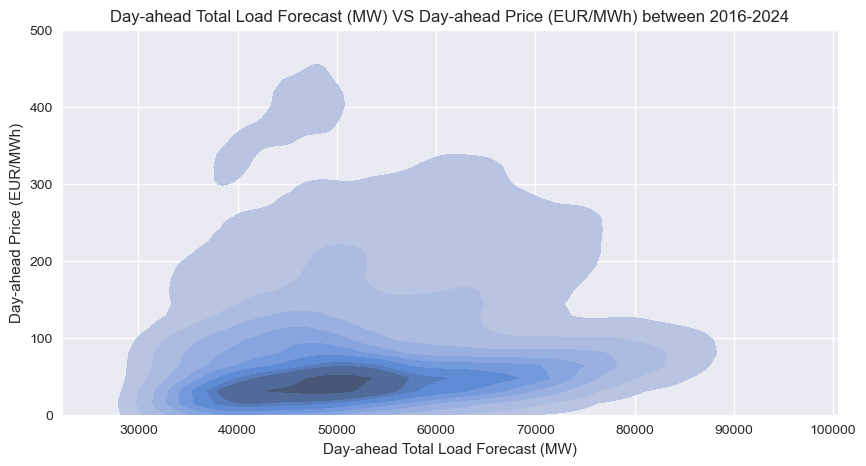

In [3]:
plt.figure(figsize = (10,5))
sns.kdeplot(data = df_alls, x = "Day-ahead Total Load Forecast (MW)_load", y = "Day-ahead Price (EUR/MWh)", fill = True)
plt.ylim(0,500)
plt.xlabel("Day-ahead Total Load Forecast (MW)")
plt.ylabel("Day-ahead Price (EUR/MWh)")
plt.title('Day-ahead Total Load Forecast (MW) VS Day-ahead Price (EUR/MWh) between 2016-2024')
plt.show()

In [4]:
df_alls[["Day-ahead Price (EUR/MWh)", "Day-ahead Total Load Forecast (MW)_load"]].corr(method = "pearson")

,Day-ahead Price (EUR/MWh),Day-ahead Total Load Forecast (MW)_load
Day-ahead Price (EUR/MWh),1.000000,0.109274
Day-ahead Total Load Forecast (MW)_load,0.109274,1.000000


In [5]:
df_alls[["Day-ahead Price (EUR/MWh)", "Day-ahead Total Load Forecast (MW)_load"]].corr(method = "spearman")

,Day-ahead Price (EUR/MWh),Day-ahead Total Load Forecast (MW)_load
Day-ahead Price (EUR/MWh),1.000000,0.238601
Day-ahead Total Load Forecast (MW)_load,0.238601,1.000000


The Pearson correlation between load and electricity price is 0.109 while the Spearman correlation is slightly higher at 0.24. Both are weak, which is itself an indication that day-ahead total load data level is a poor predictor of price.

In [6]:
df_load_bin = df_alls.assign(Forecast_load_bins = pd.qcut(df_alls["Day-ahead Total Load Forecast (MW)_load"], 20)).groupby(
                              "Forecast_load_bins", observed = True).agg(
                              load_mean = ("Day-ahead Total Load Forecast (MW)_load", "mean"),
                              price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
                              price_std = ("Day-ahead Price (EUR/MWh)", "std"),
                              price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
                              price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
                              )
df_load_bin

,load_mean,price_mean,price_std,price_90th,price_99th
Forecast_load_bins,,,,,
"(27649.999, 35850.0]",33796.868952,60.150570,81.269802,117.927,433.8982
"(35850.0, 38250.0]",37150.144602,69.007245,92.483038,163.020,468.9890
"(38250.0, 40100.0]",39230.880401,71.195394,94.402921,162.164,480.0694
"(40100.0, 41750.0]",40970.393905,72.674678,95.482669,160.032,508.2702
"(41750.0, 43350.0]",42589.207041,70.911579,88.014492,139.406,479.2193
"(43350.0, 44900.0]",44162.742024,80.387662,97.558931,171.927,508.0915
"(44900.0, 46300.0]",45629.986216,81.197287,101.137678,165.442,543.0224
"(46300.0, 47650.0]",46995.564792,85.366030,103.742342,184.949,546.3073
"(47650.0, 48950.0]",48316.368168,87.789504,109.700762,190.948,575.5274


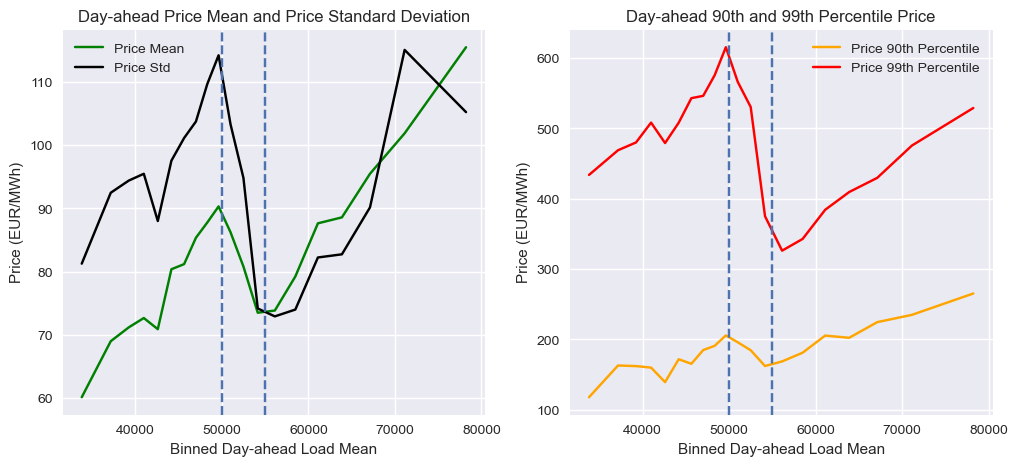

In [52]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = [12,5])
sns.lineplot(data = df_load_bin, x = "load_mean", y = "price_mean", ax = axs[0], color = "green", label = "Price Mean")
sns.lineplot(data = df_load_bin, x = "load_mean", y = "price_std", ax = axs[0], color = "black", label = "Price Std")
sns.lineplot(data = df_load_bin, x = "load_mean", y = "price_90th", ax = axs[1], color = "orange", label = "Price 90th Percentile")
sns.lineplot(data = df_load_bin, x = "load_mean", y = "price_99th", ax = axs[1], color = "red", label="Price 99th Percentile")

axs[0].set_xlabel("Binned Day-ahead Load Mean")
axs[0].set_ylabel("Price (EUR/MWh)")
axs[0].set_title("Day-ahead Price Mean and Price Standard Deviation")
axs[0].axvline(x = 50000, ls = "--")
axs[0].axvline(x = 55000, ls = "--")

axs[1].set_xlabel("Binned Day-ahead Load Mean")
axs[1].set_ylabel("Price (EUR/MWh)")
axs[1].set_title("Day-ahead 90th and 99th Percentile Price")
axs[1].axvline(x = 50000, ls = "--")
axs[1].axvline(x = 55000, ls = "--")

plt.legend()
plt.show()

After grouping day-ahead load into 20 quantile-based bins and computing the average price per bin, a clear upward trend emerges: higher load levels are generally associated with higher day-ahead prices. 

However, the relationship is not monotonic. A noticeable downward is observed at middle range load, between ~50000-55000 MW. This suggests that load alone does not fully explain price behavior. Possible explanations include:
- High renewable penetration during those load conditions,
- Differences in yearly composition (e.g., crisis-year observations).

The analysis motivates renewable and net load separations. Net load should expose a cleaner price signal.

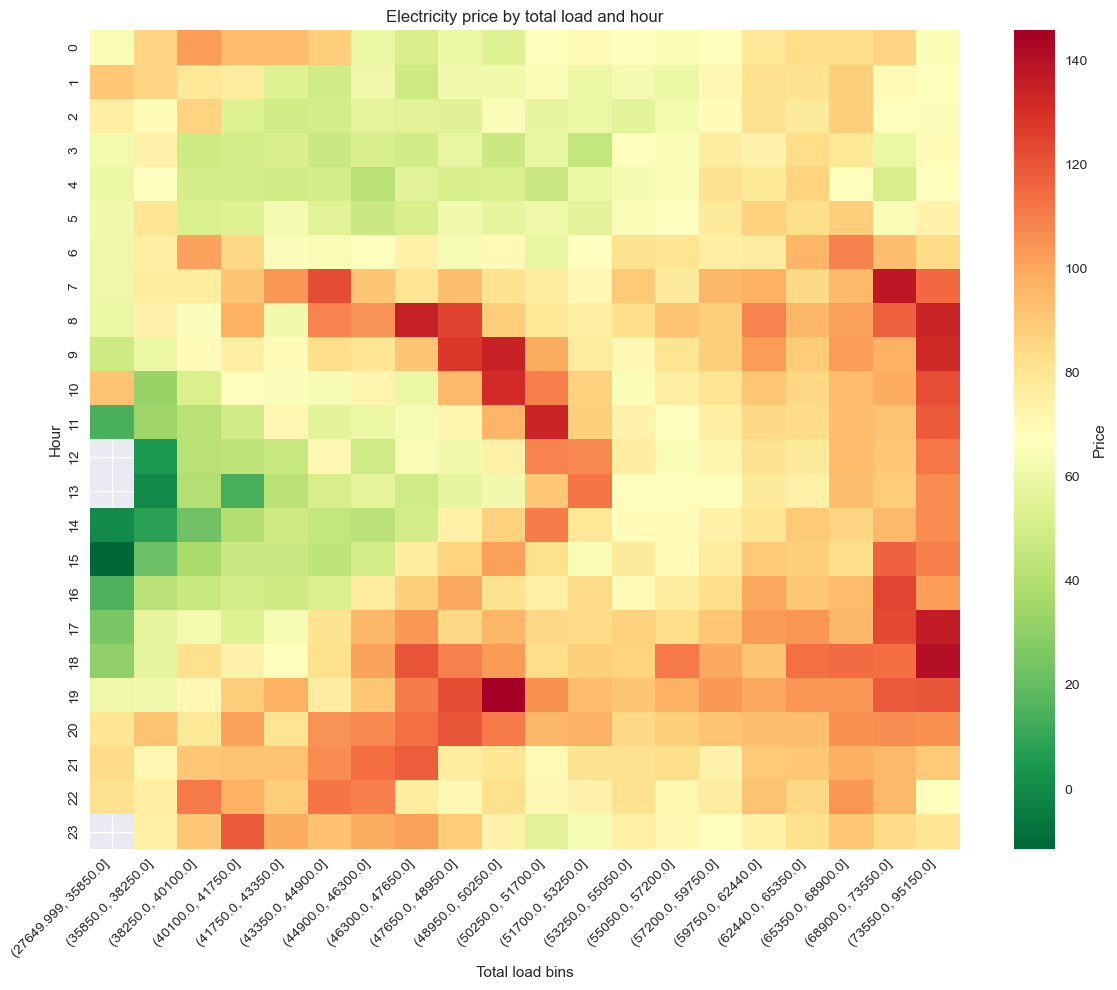

In [53]:
pivot_total_hour = df_alls.pivot_table(
    values = "Day-ahead Price (EUR/MWh)",
    index = df_alls.index.hour,
    columns = pd.qcut(df_alls["Day-ahead Total Load Forecast (MW)_load"], 20),
    aggfunc = "mean",
    observed = False
)


fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (12, 10))
sns.heatmap(pivot_total_hour, cmap = "RdYlGn_r", annot = False, cbar = True)
axes.set_title("Electricity price by total load and hour")
axes.collections[0].colorbar.set_label("Price")
axes.set_xlabel("Total load bins")
axes.set_ylabel("Hour")
plt.setp(axes.get_xticklabels(),
        rotation = 45,
        ha = "right")

plt.tight_layout()
plt.show()

The heatmap between hourly price and total load reveals the non-linear relationship as well. The hourly price tends to rise at medium and high total load. At the meantime, the price generally peaks during morning rush hours and evening hours. 

### Day-ahead Wind Load (off-shore) VS Day-ahead Price

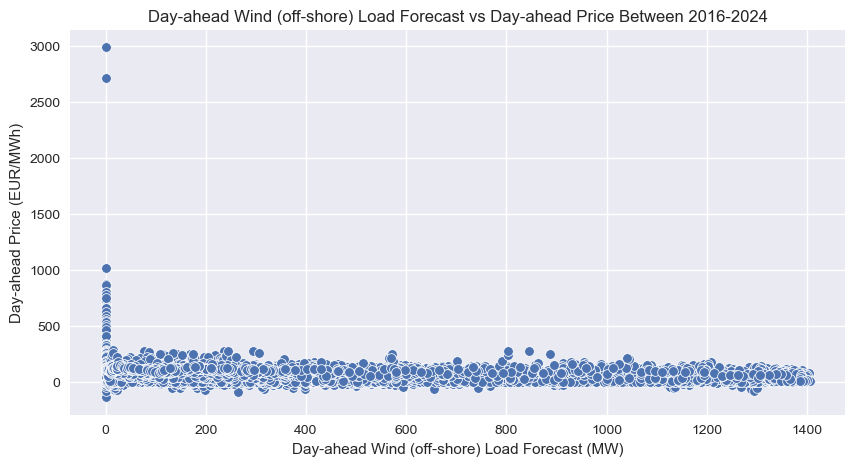

In [8]:
plt.figure(figsize = (10, 5))
sns.scatterplot(data = df_alls, x = "Day-ahead (MW)_wind_offshore", y = "Day-ahead Price (EUR/MWh)")
plt.title("Day-ahead Wind (off-shore) Load Forecast vs Day-ahead Price Between 2016-2024")
plt.xlabel("Day-ahead Wind (off-shore) Load Forecast (MW)")
plt.ylabel("Day-ahead Price (EUR/MWh)")
plt.show()

In [9]:
df_wind_offshore_load_bins = df_alls.assign(
    **{"Day-ahead (MW)_wind_offshore_bins" : pd.qcut(df_alls["Day-ahead (MW)_wind_offshore"], 30, 
                                                     duplicates= "drop")
                                                     }
    ).groupby("Day-ahead (MW)_wind_offshore_bins", observed = True).agg(
        wind_mean = ("Day-ahead (MW)_wind_offshore", "mean"),
        price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
        price_std = ("Day-ahead Price (EUR/MWh)", "std"),
        price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
        price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)
df_wind_offshore_load_bins

,wind_mean,price_mean,price_std,price_90th,price_99th
Day-ahead (MW)_wind_offshore_bins,,,,,
"(-0.001, 45.0]",0.417321,85.607356,100.620020,206.577,506.5049
"(45.0, 179.25]",106.164636,75.475356,41.750300,123.764,188.1822
"(179.25, 345.0]",255.894947,65.520452,42.875344,117.998,160.9535
"(345.0, 629.817]",464.990772,62.450502,40.059778,113.828,151.5922
"(629.817, 1406.25]",929.651083,47.943299,40.990322,105.490,149.8760


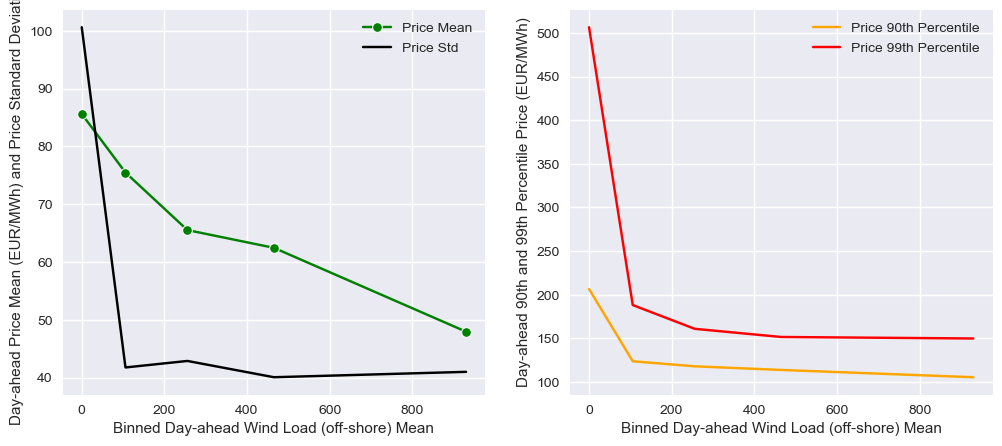

In [10]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = [12,5])
sns.lineplot(data = df_wind_offshore_load_bins, x = "wind_mean", y = "price_mean", 
             ax = axs[0], color = "green", label = "Price Mean", marker = "o")
sns.lineplot(data = df_wind_offshore_load_bins, x = "wind_mean", y = "price_std", 
             ax = axs[0], color = "black", label = "Price Std")
sns.lineplot(data = df_wind_offshore_load_bins, x = "wind_mean", y = "price_90th", 
             ax = axs[1], color = "orange", label = "Price 90th Percentile")
sns.lineplot(data = df_wind_offshore_load_bins, x = "wind_mean", y = "price_99th", 
             ax = axs[1], color = "red", label="Price 99th Percentile")

axs[0].set_xlabel("Binned Day-ahead Wind Load (off-shore) Mean")
axs[0].set_ylabel("Day-ahead Price Mean (EUR/MWh) and Price Standard Deviation")
axs[1].set_xlabel("Binned Day-ahead Wind Load (off-shore) Mean")
axs[1].set_ylabel("Day-ahead 90th and 99th Percentile Price (EUR/MWh)")

plt.legend()
plt.show()

After grouping day-ahead wind offshore load into 5 bins and computing the average price per bin, a clear downward trend emerges: higher load levels are generally associated with lower day-ahead prices. Moving from the lowest wind quantile to the highest reduces average price by ~38 EUR/MWh, and compresses the P99 from 507 to 150 EUR/MWh.

However, we need to take into account that the sample size for day-ahead wind offshore load is very limited since wind offshore data doesn't exist until 2023. This finding requires validation as more data becomes available - it cannot yet be considered representative of the full period. 

### Day-ahead Wind Load (On-shore) vs Day-ahead Price

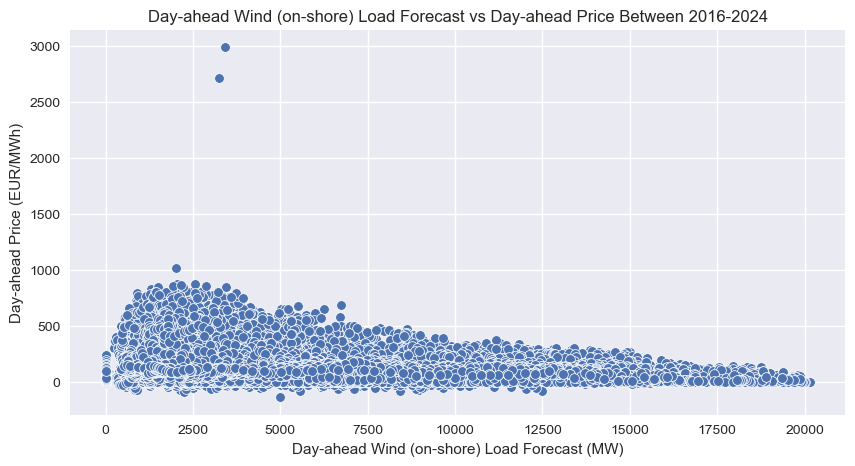

In [11]:
plt.figure(figsize = (10, 5))
sns.scatterplot(data = df_alls, x = "Day-ahead (MW)_wind_onshore", y = "Day-ahead Price (EUR/MWh)")
plt.title("Day-ahead Wind (on-shore) Load Forecast vs Day-ahead Price Between 2016-2024")
plt.xlabel("Day-ahead Wind (on-shore) Load Forecast (MW)")
plt.ylabel("Day-ahead Price (EUR/MWh)")
plt.show()

In [12]:
df_wind_onshore_load_bins = df_alls.assign(
    **{"Day-ahead (MW)_wind_onshore_bins" : pd.qcut(df_alls["Day-ahead (MW)_wind_onshore"], 20)}
    ).groupby(
        "Day-ahead (MW)_wind_onshore_bins", observed = True).agg(
            wind_mean = ("Day-ahead (MW)_wind_onshore", "mean"),
            price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
            price_std = ("Day-ahead Price (EUR/MWh)", "std"),
            price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
            price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)
df_wind_onshore_load_bins

,wind_mean,price_mean,price_std,price_90th,price_99th
Day-ahead (MW)_wind_onshore_bins,,,,,
"(-0.001, 787.71]",524.354170,60.625787,63.778156,99.264,370.2400
"(787.71, 1058.81]",928.793412,73.128548,88.619529,135.536,516.8908
"(1058.81, 1278.892]",1174.274781,79.483143,99.845809,165.816,550.1064
"(1278.892, 1476.102]",1376.331404,81.505775,101.371702,181.200,552.0370
"(1476.102, 1679.978]",1576.622900,86.766233,107.472445,208.820,543.8732
"(1679.978, 1887.333]",1784.819932,87.869141,107.466272,208.245,550.0000
"(1887.333, 2101.121]",1994.091275,88.527952,107.734014,214.934,537.8464
"(2101.121, 2328.094]",2212.929914,89.878107,107.020906,215.510,542.8330
"(2328.094, 2571.925]",2449.347093,90.224636,103.388980,207.606,517.0064


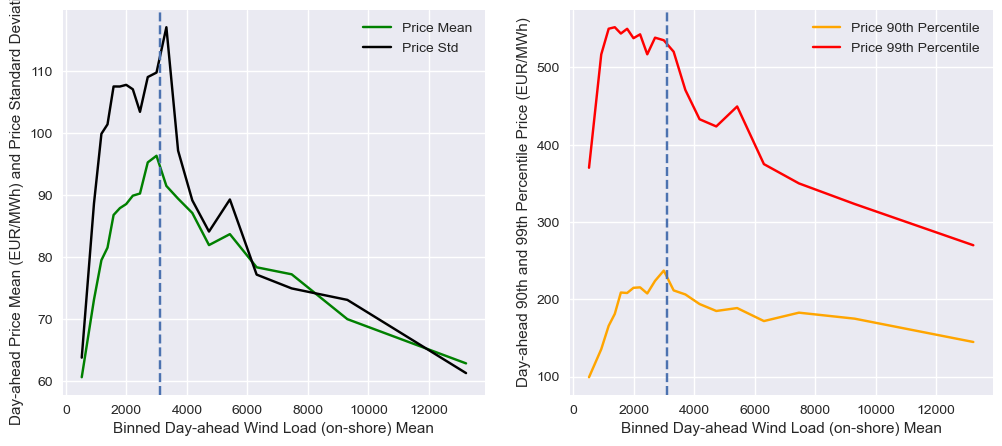

In [13]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = [12,5])
sns.lineplot(data = df_wind_onshore_load_bins, x = "wind_mean", y = "price_mean", ax = axs[0], color = "green", label = "Price Mean")
sns.lineplot(data = df_wind_onshore_load_bins, x = "wind_mean", y = "price_std", ax = axs[0], color = "black", label = "Price Std")
sns.lineplot(data = df_wind_onshore_load_bins, x = "wind_mean", y = "price_90th", ax = axs[1], color = "orange", label = "Price 90th Percentile")
sns.lineplot(data = df_wind_onshore_load_bins, x = "wind_mean", y = "price_99th", ax = axs[1], color = "red", label="Price 99th Percentile")

axs[0].set_xlabel("Binned Day-ahead Wind Load (on-shore) Mean")
axs[0].set_ylabel("Day-ahead Price Mean (EUR/MWh) and Price Standard Deviation")
axs[1].set_xlabel("Binned Day-ahead Wind Load (on-shore) Mean")
axs[1].set_ylabel("Day-ahead 90th and 99th Percentile Price (EUR/MWh)")
axs[0].axvline(x = 3100, ls = "--")
axs[1].axvline(x = 3100, ls = "--")
plt.legend()
plt.show()

The analysis indicates a nonlinear relationship between onshore wind output and day-ahead price levels. 

In low-output regimes, price levels and volatility remain elevated, with pronounced upper-tail risk (P99). 

As onshore wind increases beyond ~3.1 GW, both average prices and tail dispersion compress, suggesting displacement of higher-cost marginal units. Moving from the elbow point of the wind onshore output to the highest reduces average price by ~33 EUR/MWh, and compresses the P99 from 539 to 270 EUR/MWh.

However, onshore wind alone does not fully determine the marginal cost regime, as other renewable sources and demand dynamics may simultaneously influence price formation.

The 3.1 GW threshold where price compression begins will be a relevant reference for the modelling section's feature engineering. 

### Day-ahead Total Wind Load vs Day-ahead Price

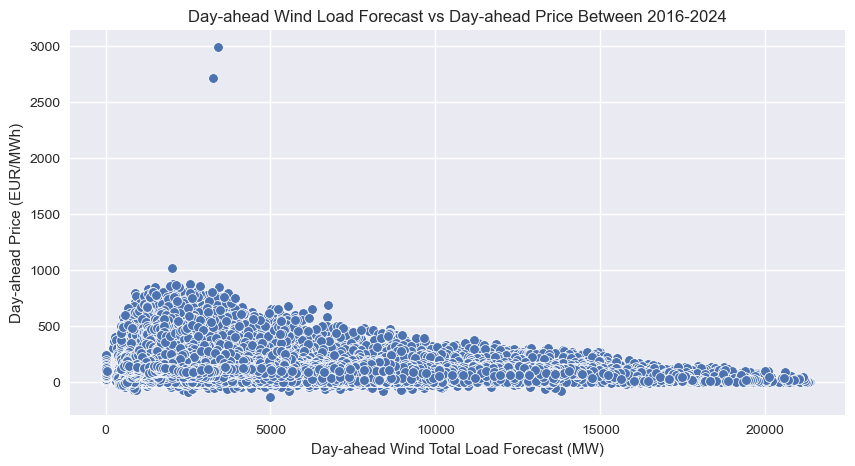

In [14]:
df_alls["Day-ahead (MW)_wind_total"] = (
    df_alls["Day-ahead (MW)_wind_offshore"] + df_alls["Day-ahead (MW)_wind_onshore"])

plt.figure(figsize = (10, 5))
sns.scatterplot(data = df_alls, x = "Day-ahead (MW)_wind_total", y = "Day-ahead Price (EUR/MWh)")
plt.title("Day-ahead Wind Load Forecast vs Day-ahead Price Between 2016-2024")
plt.xlabel("Day-ahead Wind Total Load Forecast (MW)")
plt.ylabel("Day-ahead Price (EUR/MWh)")
plt.show()

In [15]:
df_day_ahead_wind_total_bins = df_alls.assign(
    **{"Day-ahead (MW)_wind_total_bins" : pd.qcut(df_alls["Day-ahead (MW)_wind_total"], 20)}
    ).groupby("Day-ahead (MW)_wind_total_bins", observed = True).agg(
        wind_mean = ("Day-ahead (MW)_wind_total", "mean"),
        price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
        price_std = ("Day-ahead Price (EUR/MWh)", "std"),
        price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
        price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)
df_day_ahead_wind_total_bins

,wind_mean,price_mean,price_std,price_90th,price_99th
Day-ahead (MW)_wind_total_bins,,,,,
"(-0.001, 790.79]",526.231036,60.745979,64.342484,99.110,372.5682
"(790.79, 1063.314]",932.951452,73.328616,88.664684,137.980,516.8908
"(1063.314, 1286.776]",1180.892586,80.111620,102.552682,170.356,566.5768
"(1286.776, 1484.682]",1385.651847,81.023434,100.703812,182.855,537.5635
"(1484.682, 1694.668]",1588.170003,87.053323,108.803681,209.850,557.1504
"(1694.668, 1901.239]",1798.238540,88.778256,106.797021,211.490,540.0415
"(1901.239, 2119.308]",2010.754038,90.121878,110.170976,220.000,549.1068
"(2119.308, 2350.836]",2233.614245,88.784524,104.615763,209.455,534.5945
"(2350.836, 2599.96]",2474.468946,91.041095,104.645901,211.145,519.6665


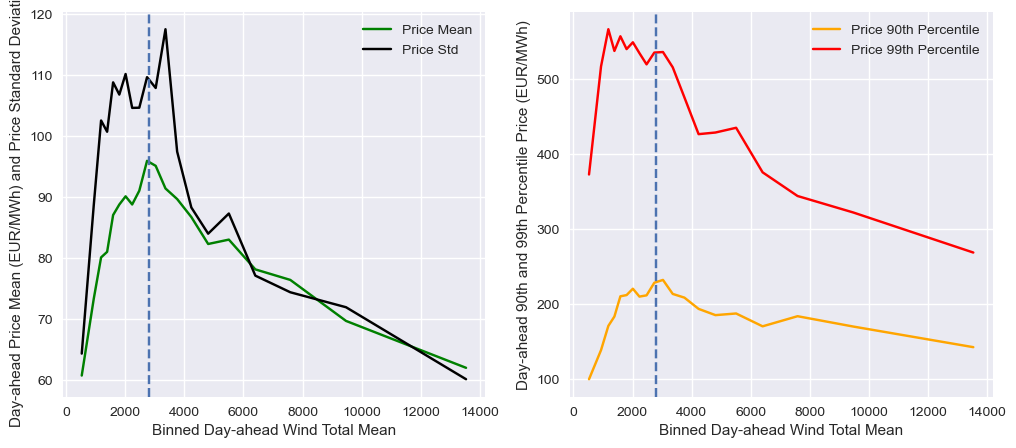

In [16]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = [12,5])
sns.lineplot(data = df_day_ahead_wind_total_bins, x = "wind_mean", y = "price_mean", ax = axs[0], color = "green", label = "Price Mean")
sns.lineplot(data = df_day_ahead_wind_total_bins, x = "wind_mean", y = "price_std", ax = axs[0], color = "black", label = "Price Std")
sns.lineplot(data = df_day_ahead_wind_total_bins, x = "wind_mean", y = "price_90th", ax = axs[1], color = "orange", label = "Price 90th Percentile")
sns.lineplot(data = df_day_ahead_wind_total_bins, x = "wind_mean", y = "price_99th", ax = axs[1], color = "red", label="Price 99th Percentile")

axs[0].set_xlabel("Binned Day-ahead Wind Total Mean")
axs[0].set_ylabel("Day-ahead Price Mean (EUR/MWh) and Price Standard Deviation")
axs[0].axvline(x = 2800, ls = "--")
axs[1].set_xlabel("Binned Day-ahead Wind Total Mean")
axs[1].set_ylabel("Day-ahead 90th and 99th Percentile Price (EUR/MWh)")
axs[1].axvline(x = 2800, ls = "--")

plt.legend()
plt.show()

The analysis indicates a nonlinear relationship between total wind output and day-ahead price levels. 

In low-output regimes, price levels and volatility remain elevated, with pronounced upper-tail risk (P99). 

As total wind output increases beyond ~2.8 GW, both average prices and tail dispersion compress, suggesting displacement of higher-cost marginal units. The average price drops from 96 to 62 EUR/MWh. P99 compresses from 567 to 268 EUR/MWh.  

However, total wind alone does not fully determine the marginal cost regime, as other renewable sources and demand dynamics may simultaneously influence price formation.

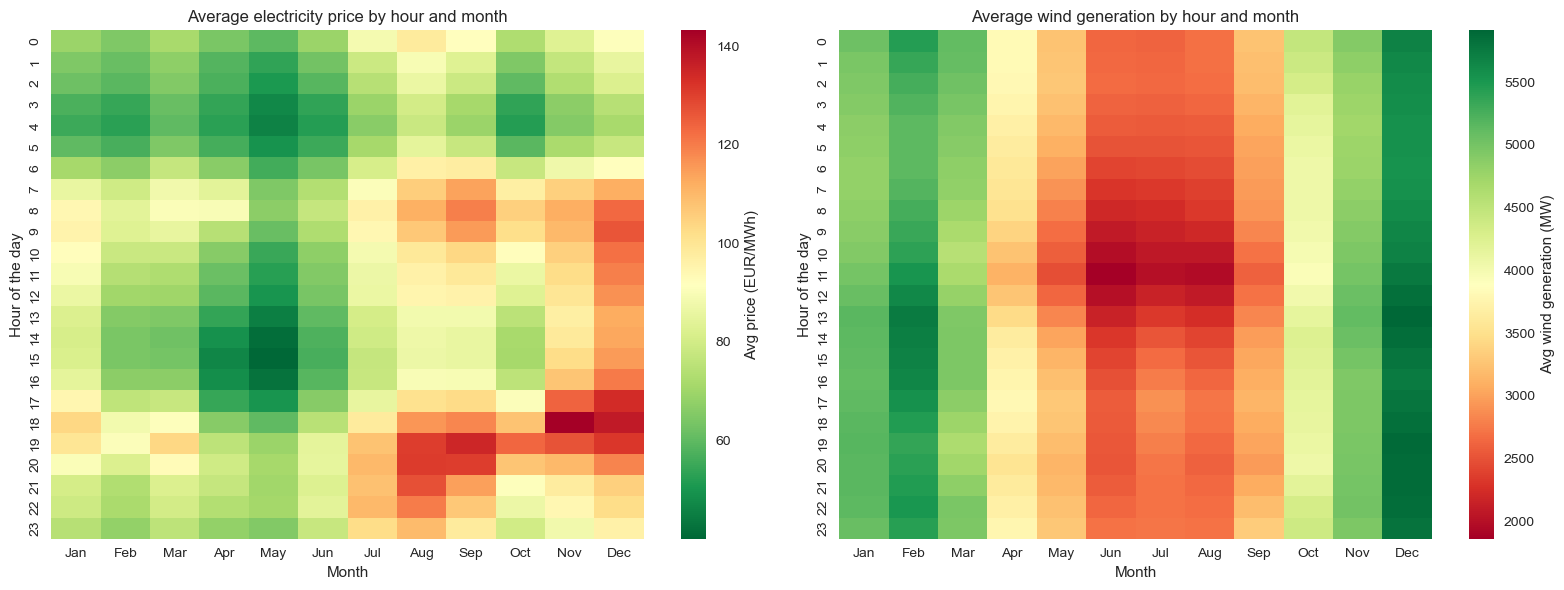

In [17]:
fig, axes = plt.subplots(1,2, figsize = (16, 6))

price_hourly_monthly = df_alls.groupby(
    [df_alls.index.month, df_alls.index.hour]
)["Day-ahead Price (EUR/MWh)"].mean().unstack(level = 0)

price_hourly_monthly.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

sns.heatmap(price_hourly_monthly, ax = axes[0], cmap = "RdYlGn_r", 
            cbar_kws = {"label": "Avg price (EUR/MWh)"})
axes[0].set_title("Average electricity price by hour and month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Hour of the day")

wind_hourly_monthly = df_alls.groupby(
    [df_alls.index.month, df_alls.index.hour]
)["Day-ahead (MW)_wind_total"].mean().unstack(level = 0)
wind_hourly_monthly.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

sns.heatmap(wind_hourly_monthly, ax = axes[1], cmap = "RdYlGn",
            cbar_kws = {"label": "Avg wind generation (MW)"})
axes[1].set_title("Average wind generation by hour and month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Hour of the day")

plt.tight_layout()
plt.show()

Wind generations don't have a systematic interday cycle, therefore, hourly and monthly averaged wind generation doesn't show spatial correlation with the hourly and monthly averaged price. The price suppressing effect of wind is confirmed by the binned analysis above. 

### Day-ahead Solar Load VS Day-ahead Price

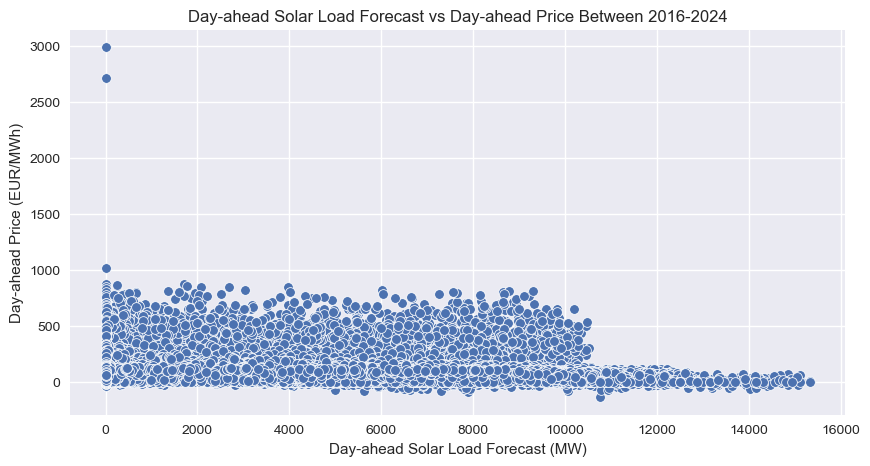

In [18]:
plt.figure(figsize = (10, 5))
sns.scatterplot(data = df_alls, x = "Day-ahead (MW)_solar", y = "Day-ahead Price (EUR/MWh)")
plt.title("Day-ahead Solar Load Forecast vs Day-ahead Price Between 2016-2024")
plt.xlabel("Day-ahead Solar Load Forecast (MW)")
plt.ylabel("Day-ahead Price (EUR/MWh)")
plt.show()

In [19]:
df_solar_day_ahead_nonzero = df_alls[df_alls["Day-ahead (MW)_solar"] > 0].copy()

In [20]:
df_solar_load_bins = df_solar_day_ahead_nonzero.assign(
    **{"Day-ahead (MW)_solar_bins" : 
       pd.qcut(df_solar_day_ahead_nonzero["Day-ahead (MW)_solar"], 20, duplicates = "drop")}
        ).groupby("Day-ahead (MW)_solar_bins", observed = True).agg(
            solar_mean = ("Day-ahead (MW)_solar", "mean"),
            price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
            price_std = ("Day-ahead Price (EUR/MWh)", "std"),
            price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
            price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)
df_solar_load_bins

,solar_mean,price_mean,price_std,price_90th,price_99th
Day-ahead (MW)_solar_bins,,,,,
"(0.009000000000000001, 15.71]",3.501409,88.208915,99.461145,190.000,537.8708
"(15.71, 111.885]",56.939025,90.625965,97.100305,201.816,516.5534
"(111.885, 273.74]",184.128973,91.864927,103.982311,217.268,535.2873
"(273.74, 536.08]",395.102511,92.360902,103.356990,213.938,543.8028
"(536.08, 845.112]",684.688250,80.954566,88.013612,159.272,481.9114
"(845.112, 1203.45]",1021.580853,84.448163,95.925342,160.604,558.0028
"(1203.45, 1547.517]",1377.999840,84.406413,97.162492,200.490,503.2648
"(1547.517, 1891.23]",1720.848232,79.845562,87.637867,158.439,476.3800
"(1891.23, 2232.892]",2062.895972,75.115177,85.182709,141.614,459.1318


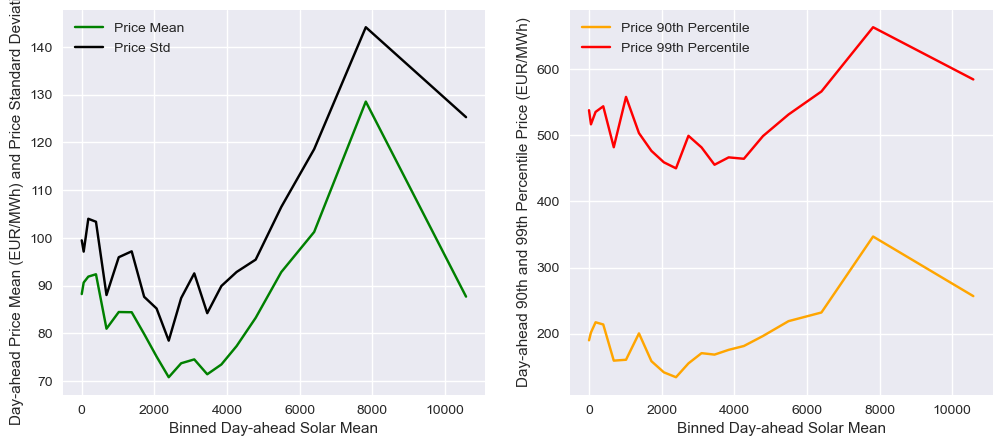

In [21]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = [12,5])
sns.lineplot(data = df_solar_load_bins, x = "solar_mean", y = "price_mean", ax = axs[0], color = "green", label = "Price Mean")
sns.lineplot(data = df_solar_load_bins, x = "solar_mean", y = "price_std", ax = axs[0], color = "black", label = "Price Std")
sns.lineplot(data = df_solar_load_bins, x = "solar_mean", y = "price_90th", ax = axs[1], color = "orange", label = "Price 90th Percentile")
sns.lineplot(data = df_solar_load_bins, x = "solar_mean", y = "price_99th", ax = axs[1], color = "red", label="Price 99th Percentile")

axs[0].set_xlabel("Binned Day-ahead Solar Mean")
axs[0].set_ylabel("Day-ahead Price Mean (EUR/MWh) and Price Standard Deviation")
axs[1].set_xlabel("Binned Day-ahead Solar Mean")
axs[1].set_ylabel("Day-ahead 90th and 99th Percentile Price (EUR/MWh)")

plt.legend()
plt.show()

After grouping day-ahead solar load into 20 quantile-based bins and computing the average price per bin, a non-linear curve emerges: at low solar generations, likely corresponding to early morning and late afternoon shoulder hours, the prices are high due to morning industrial demand. As solar output exceeds roughly 4 GW, it begins displacing higher-cost marginal generation, suppressing average price from about 129 EUR/MWh down to about 88 EUR/MWh at peak output. Tail rish (P99) compresses similarly, from 663 to 583 EUR/MWh.

This non-linear threshold effect reflects the merit order mechanism: solar only shifts the marginal price when its output is large enough to displace dispatchable units.

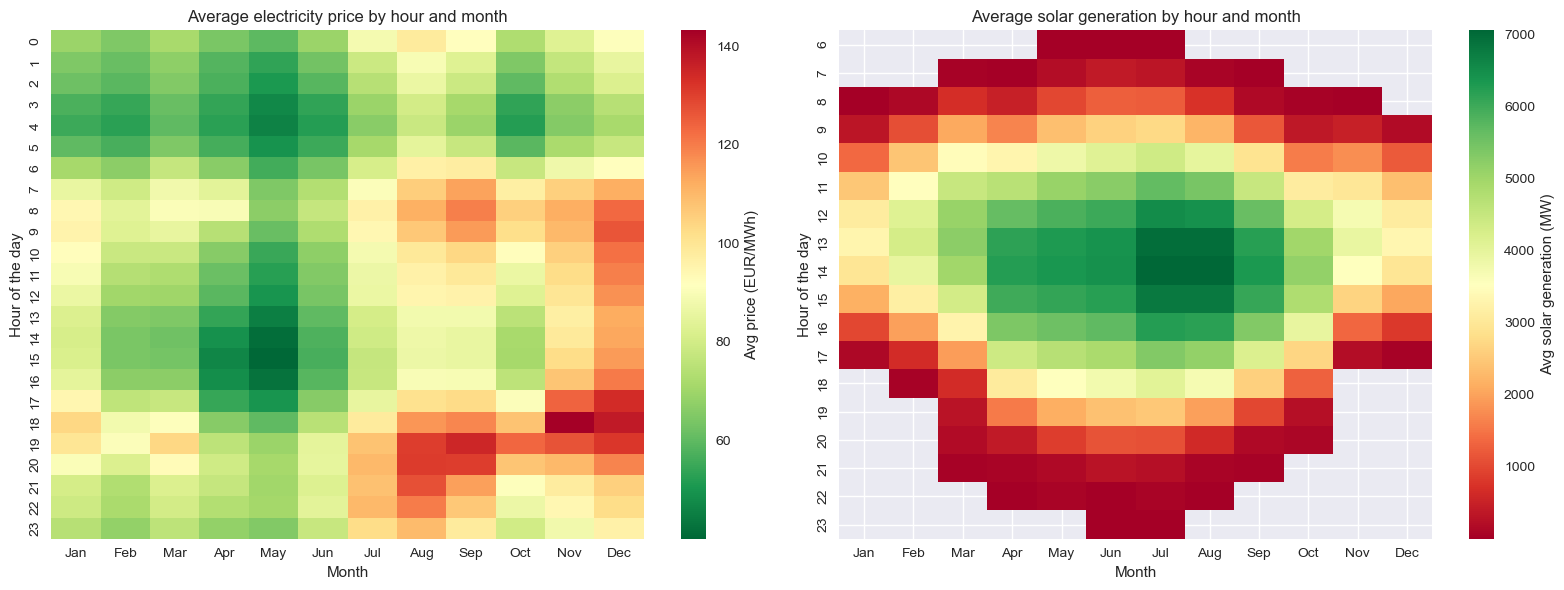

In [22]:
fig, axes = plt.subplots(1,2, figsize = (16, 6))

sns.heatmap(price_hourly_monthly, ax = axes[0], cmap = "RdYlGn_r", 
            cbar_kws = {"label": "Avg price (EUR/MWh)"})
axes[0].set_title("Average electricity price by hour and month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Hour of the day")

solar_hourly_monthly = df_solar_day_ahead_nonzero.groupby(
    [df_solar_day_ahead_nonzero.index.month, df_solar_day_ahead_nonzero.index.hour]
)["Day-ahead (MW)_solar"].mean().unstack(level = 0)
solar_hourly_monthly.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

sns.heatmap(solar_hourly_monthly, ax = axes[1], cmap = "RdYlGn",
            cbar_kws = {"label": "Avg solar generation (MW)"})
axes[1].set_title("Average solar generation by hour and month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Hour of the day")

plt.tight_layout()
plt.show()

Hourly and monthly averaged price show partial correlation with the hourly and monthly averaged solar generations. 

**The relationship between renewable generation and day-ahead price exhibits heterogeneous behavior across technologies. The day-ahead price is not influenced by a single renewables.**

### Day-ahead Net Load

In [23]:
df_alls["net_load"] = (df_alls["Day-ahead Total Load Forecast (MW)_load"] - 
                       (df_alls["Day-ahead (MW)_wind_offshore"] 
                        + df_alls["Day-ahead (MW)_wind_onshore"]
                        + df_alls["Day-ahead (MW)_solar"]))

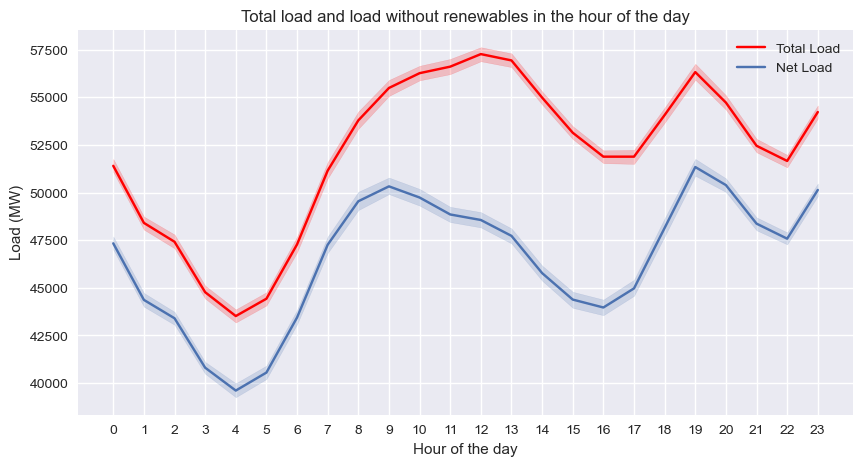

In [55]:
plt.figure(figsize = (10, 5))
sns.lineplot(data = df_alls, x = df_alls.index.hour, y = "Day-ahead Total Load Forecast (MW)_load", 
             color = "red", label = "Total Load")
sns.lineplot(data = df_alls, x = df_alls.index.hour, y = "net_load", label = "Net Load")

plt.xticks(range(0, 24))
plt.xlabel("Hour of the day")
plt.ylabel("Load (MW)")
plt.title("Total load and load without renewables in the hour of the day")
plt.legend()
plt.show()

The gap between total load and net load opens up between 9:00 to 16:00. Between 16:00 to 19:00 the gap decreases due to the decrease in solar input and the increase in demand. 

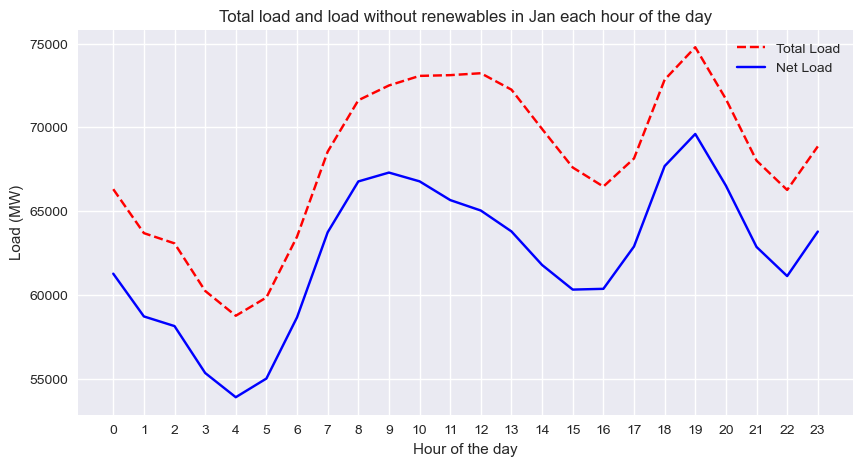

In [25]:
jan_load = df_alls[df_alls.index.month == 1].groupby(df_alls[df_alls.index.month == 1].index.hour).agg(
    total_load = ("Day-ahead Total Load Forecast (MW)_load", "mean"),
    net_load = ("net_load", "mean")
)
plt.figure(figsize = (10, 5))
plt.plot(jan_load.index, jan_load["total_load"], color = "red", ls = "--", label = "Total Load")
plt.plot(jan_load.index, jan_load["net_load"], color = "blue", label = "Net Load")
plt.xlabel("Hour of the day")
plt.ylabel("Load (MW)")
plt.title("Total load and load without renewables in Jan each hour of the day")
plt.xticks(range(0, 24))
plt.legend()
plt.show()

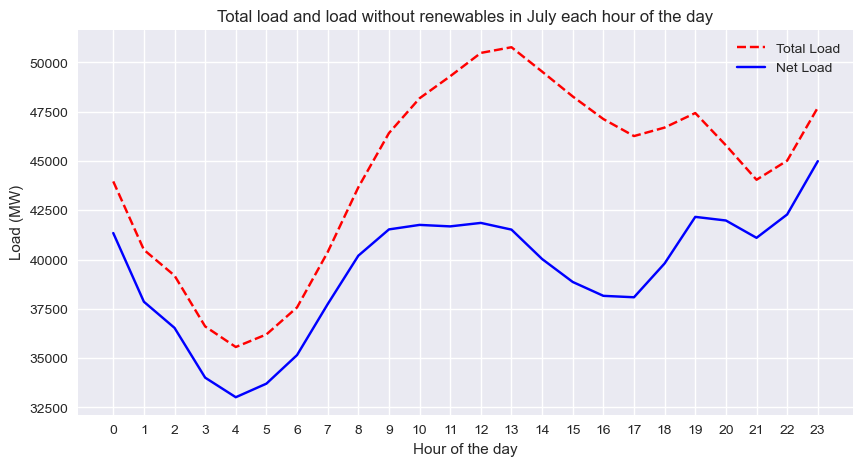

In [26]:
july_load = df_alls[df_alls.index.month == 7].groupby(df_alls[df_alls.index.month == 7].index.hour).agg(
    total_load = ("Day-ahead Total Load Forecast (MW)_load", "mean"),
    net_load = ("net_load", "mean")
)

plt.figure(figsize = (10,5))
plt.plot(july_load.index, july_load["total_load"], ls = "--", color = "red", label = "Total Load")
plt.plot(july_load.index, july_load["net_load"], color = "blue", label = "Net Load")
plt.xlabel("Hour of the day")
plt.ylabel("Load (MW)")
plt.title("Total load and load without renewables in July each hour of the day")
plt.xticks(range(0,24))
plt.legend()
plt.show()

The July profile exhibits the characteristic duck curve shape: net load remains flat and dips between 9:00 and 16:00 as solar displaces thermal generations, then ramps up towards the evening peak as solar output collapses. The January profile shows no such shape, confirming solar as a driver. 

In [27]:
df_net_load_bins = df_alls.assign(
    net_load_bins = pd.qcut(df_alls["net_load"], 20)
).groupby("net_load_bins", observed = True).agg(
    net_load_mean = ("net_load", "mean"),
    price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
    price_std = ("Day-ahead Price (EUR/MWh)", "std"),
    price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
    price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)

In [28]:
df_net_load_bins

,net_load_mean,price_mean,price_std,price_90th,price_99th
net_load_bins,,,,,
"(12104.749, 30183.094]",27300.712230,43.206277,69.214137,95.340,380.0045
"(30183.094, 32768.617]",31586.050421,64.751835,83.499518,145.255,434.5805
"(32768.617, 34588.428]",33702.215883,71.743511,88.974987,161.724,450.3240
"(34588.428, 36179.884]",35397.259838,74.169085,89.954162,168.075,459.9330
"(36179.884, 37593.662]",36900.123521,77.770507,94.089998,168.106,482.3048
"(37593.662, 38992.82]",38292.882038,83.015618,98.693191,183.320,505.4765
"(38992.82, 40316.568]",39655.495564,87.688390,105.777468,190.536,536.8724
"(40316.568, 41677.06]",40997.963742,93.680844,114.988653,202.798,600.0462
"(41677.06, 43085.984]",42374.390172,97.487302,118.446975,220.509,617.8447


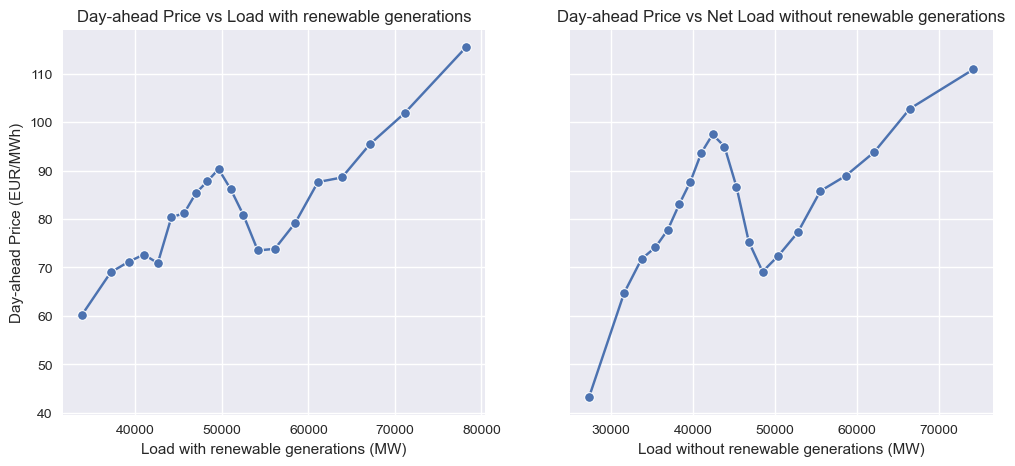

In [29]:
fig, axs = plt.subplots(ncols = 2, figsize = [12, 5], sharey= True)
sns.lineplot(data = df_load_bin, x = "load_mean", y = "price_mean", marker = "o", ax = axs[0])
sns.lineplot(data = df_net_load_bins, x = "net_load_mean", y = "price_mean", marker = "o", ax = axs[1])
axs[0].set_xlabel("Load with renewable generations (MW)")
axs[0].set_ylabel("Day-ahead Price (EUR/MWh)")

axs[0].set_title("Day-ahead Price vs Load with renewable generations")

axs[1].set_xlabel("Load without renewable generations (MW)")
axs[1].set_ylabel("Day-ahead Price (EUR/MWh)")
axs[1].set_title("Day-ahead Price vs Net Load without renewable generations")
plt.show()

The trend between day-ahead price vs total load and vs net load has a similar shape. The price increases as total load increases until 50000 MW with little fluctuations. Between 50000 - 55000 MW the price descends from 90 to 72 EUR/MWh. After 55000 MW the price goes up again as total load increases in the nearly linear fashion. For the case of net load vs day-ahead price, the price increases as the net load increases until about 41000 MW. Between 41000 - 49000 MW the price descends from 100 to 70 EUR/MWh. As the net load increases, the price grows nearly linearly. 

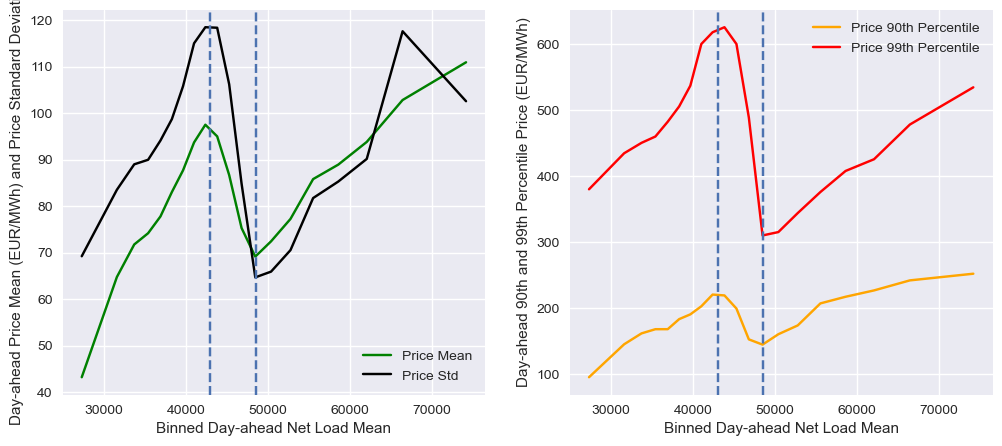

In [30]:
fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = [12,5])
sns.lineplot(data = df_net_load_bins, x = "net_load_mean", y = "price_mean", ax = axs[0], color = "green", label = "Price Mean")
sns.lineplot(data = df_net_load_bins, x = "net_load_mean", y = "price_std", ax = axs[0], color = "black", label = "Price Std")
sns.lineplot(data = df_net_load_bins, x = "net_load_mean", y = "price_90th", ax = axs[1], color = "orange", label = "Price 90th Percentile")
sns.lineplot(data = df_net_load_bins, x = "net_load_mean", y = "price_99th", ax = axs[1], color = "red", label="Price 99th Percentile")

axs[0].set_xlabel("Binned Day-ahead Net Load Mean")
axs[0].set_ylabel("Day-ahead Price Mean (EUR/MWh) and Price Standard Deviation")
axs[0].axvline(x = 43000, ls = "--")
axs[0].axvline(x = 48500, ls = "--")

axs[1].set_xlabel("Binned Day-ahead Net Load Mean")
axs[1].set_ylabel("Day-ahead 90th and 99th Percentile Price (EUR/MWh)")
axs[1].axvline(x = 43000, ls = "--")
axs[1].axvline(x = 48500, ls = "--")

plt.legend()
plt.show()

The increase of net load accompanies the increase of the day-ahead price. When net load reaches 43000 MW, the average and variability of the price decrease from 97 to 72 EUR/MWh until the net load reaches 48500 MW. After this net load, the average price increases to 111 EUR/MWh. 

P99 follows the similar trend that increases from 380 to 625 EUR/MWh, then down to 310, followed by an increase up to 534 EUR/MWh.

The decrease of price mean is probably linked to the contribution of renewble generations.

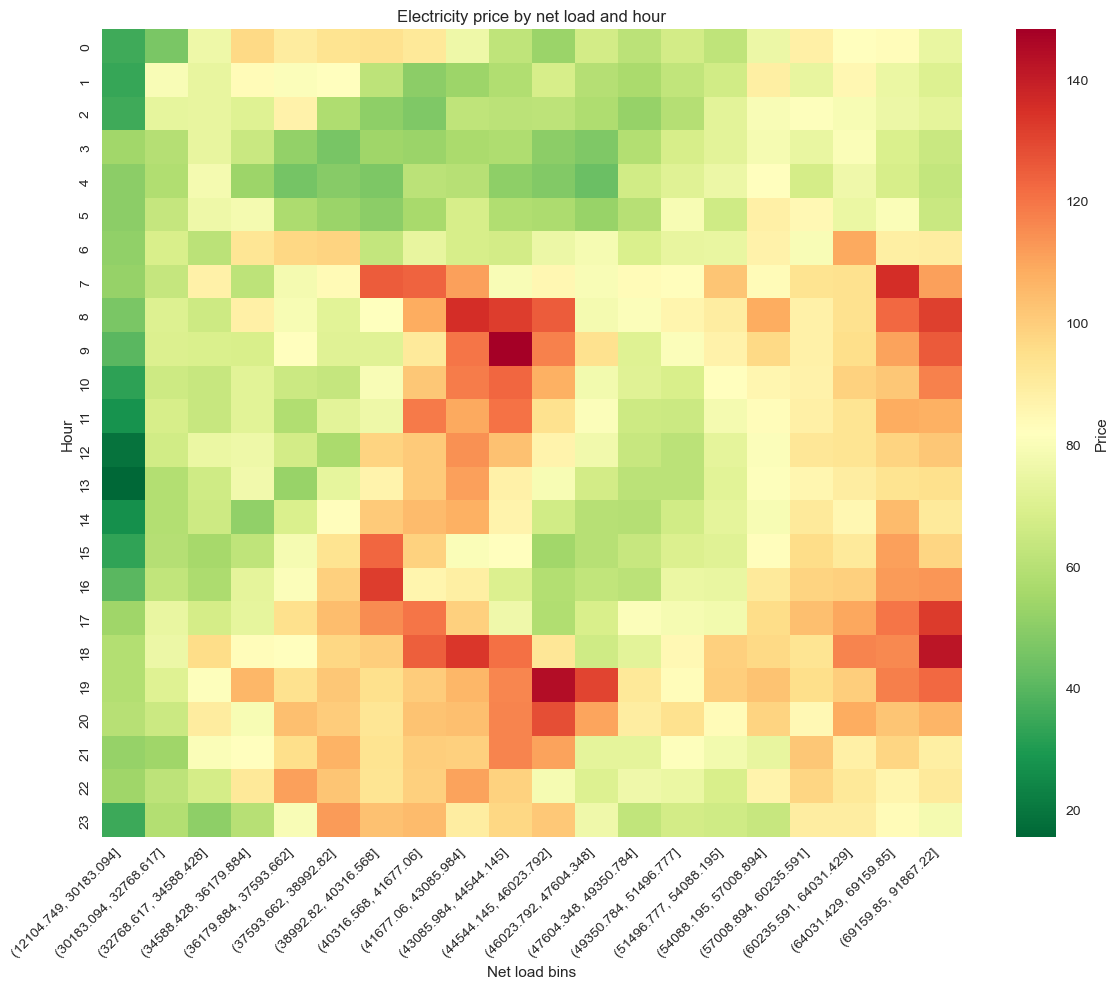

In [34]:
pivot_net_hour = df_alls.pivot_table(
    values = "Day-ahead Price (EUR/MWh)",
    index = df_alls.index.hour,
    columns = pd.qcut(df_alls["net_load"], 20),
    aggfunc = "mean",
    observed = False
)


fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (12, 10))
sns.heatmap(pivot_net_hour, cmap = "RdYlGn_r", annot = False, cbar = True)
axes.set_title("Electricity price by net load and hour")
axes.collections[0].colorbar.set_label("Price")
axes.set_xlabel("Net load bins")
axes.set_ylabel("Hour")
plt.setp(axes.get_xticklabels(),
        rotation = 45,
        ha = "right")

plt.tight_layout()
plt.show()

The heatmap reveals that the price-net load relationship is not uniform across hours. 

At extremely low net load range (below 33000 MW), the price is low across the whole day. When the net load ranges between 33000 to 39000 MW the price shows two increases during the day: once 6:00-8:00 and once 17:00-1:00. As the net load demand increases between 39000 to 47000 MW, the price increases between 7:00-1:00 with extremely high price occurs between 7:00 to 10:00 and 16:00 to 20:00. Net load range between 47000 to 54000 MW is correlated with lower price. Beyond 54000 MW, as the net load demand increases the price also increases especially between 6:00-23:00. Some extreme price cases occur when the net load is above 65000 MW and between 7:00-9:00 and 17:00-19:00. 

At extreme demand levels, scarcity dominates over time-of-the-day effects.


### Day-ahead Renewables 

In [69]:
df_alls["renewable_load"] = (df_alls["Day-ahead (MW)_wind_offshore"] 
                        + df_alls["Day-ahead (MW)_wind_onshore"]
                        + df_alls["Day-ahead (MW)_solar"])

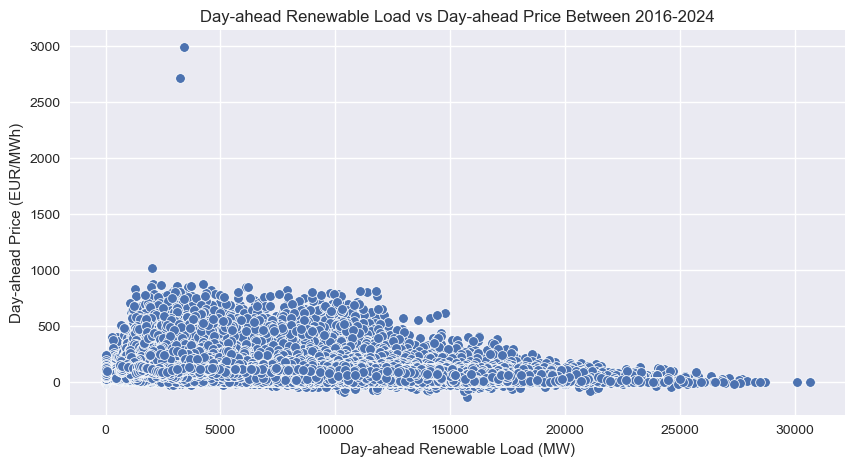

In [ ]:
plt.figure(figsize = [10, 5])
sns.scatterplot(data = df_alls, x = "renewable_load", y ="Day-ahead Price (EUR/MWh)")
plt.title("Day-ahead Renewable Load vs Day-ahead Price Between 2016-2024")
plt.xlabel("Day-ahead Renewable Load (MW)")
plt.ylabel("Day-ahead Price (EUR/MWh)")
plt.show()

In [ ]:
df_renew_load_bins = df_alls.assign(renew_load_bins = pd.qcut(df_alls["renewable_load"], 20)
                                    ).groupby("renew_load_bins", observed = True).agg(
                                        renew_load_mean = ("renewable_load", "mean"),
                                        price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
                                        price_std = ("Day-ahead Price (EUR/MWh)", "std"),
                                        price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
                                        price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
                                    )
df_renew_load_bins

,renew_load_mean,price_mean,price_std,price_90th,price_99th
renew_load_bins,,,,,
"(-0.001, 1212.506]",839.303893,62.952131,67.679273,110.950,377.0025
"(1212.506, 1572.76]",1397.758277,72.727676,84.609901,138.955,473.2095
"(1572.76, 1898.086]",1738.176385,81.694474,96.950204,191.722,500.0560
"(1898.086, 2226.328]",2061.940522,84.077456,98.328401,200.050,534.5945
"(2226.328, 2555.622]",2392.196198,86.760639,97.454679,198.712,508.5668
"(2555.622, 2906.578]",2731.766472,90.789159,102.482477,220.900,516.9575
"(2906.578, 3267.08]",3086.227263,91.727631,112.656881,209.415,546.1855
"(3267.08, 3654.08]",3458.816791,85.955095,102.568643,196.242,483.9212
"(3654.08, 4072.594]",3862.734373,85.250122,96.304689,192.434,518.4736


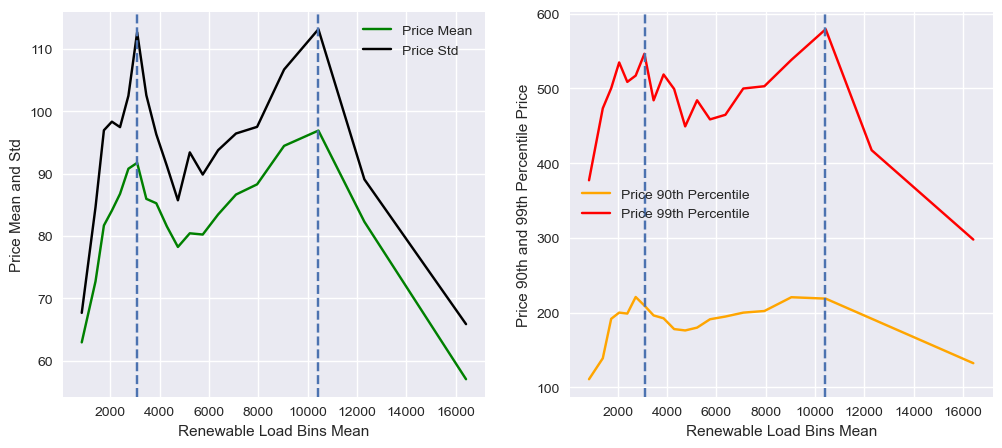

In [ ]:
fig, axes = plt.subplots(ncols = 2, figsize = (12, 5))
sns.lineplot(data = df_renew_load_bins, x = "renew_load_mean", y = "price_mean", ax = axes[0], color = "green", label = "Price Mean")
sns.lineplot(data = df_renew_load_bins, x = "renew_load_mean", y = "price_std", ax = axes[0], color = "black", label = "Price Std")
sns.lineplot(data = df_renew_load_bins, x = "renew_load_mean", y = "price_90th", ax = axes[1], color = "orange", label = "Price 90th Percentile")
sns.lineplot(data = df_renew_load_bins, x = "renew_load_mean", y = "price_99th", ax = axes[1], color = "red", label = "Price 99th Percentile")

axes[0].set_xlabel("Renewable Load Bins Mean")
axes[0].set_ylabel("Price Mean and Std")
axes[0].axvline(x = 3100, ls = "--")
axes[0].axvline(x = 10400, ls = "--")

axes[1].set_xlabel("Renewable Load Bins Mean")
axes[1].set_ylabel("Price 90th and 99th Percentile Price")
axes[1].axvline(x = 3100, ls = "--")
axes[1].axvline(x = 10400, ls = "--")

plt.legend()
plt.show()

The mean price and renewable load shows a non-linear threshold relationship. The mean price increases when the renewable load is low, at about 3100 MW the mean price starts to descrease from 92 to 80 EUR/MWh and increase again up to 97 EUR/MWh at renewable load about 10400 MW. The mean price decreases again afterwards. P99 shows similar trend as mean price as renewable output increases. From 10400 MW the renewable generations compresses the price 99th percentile significantly.

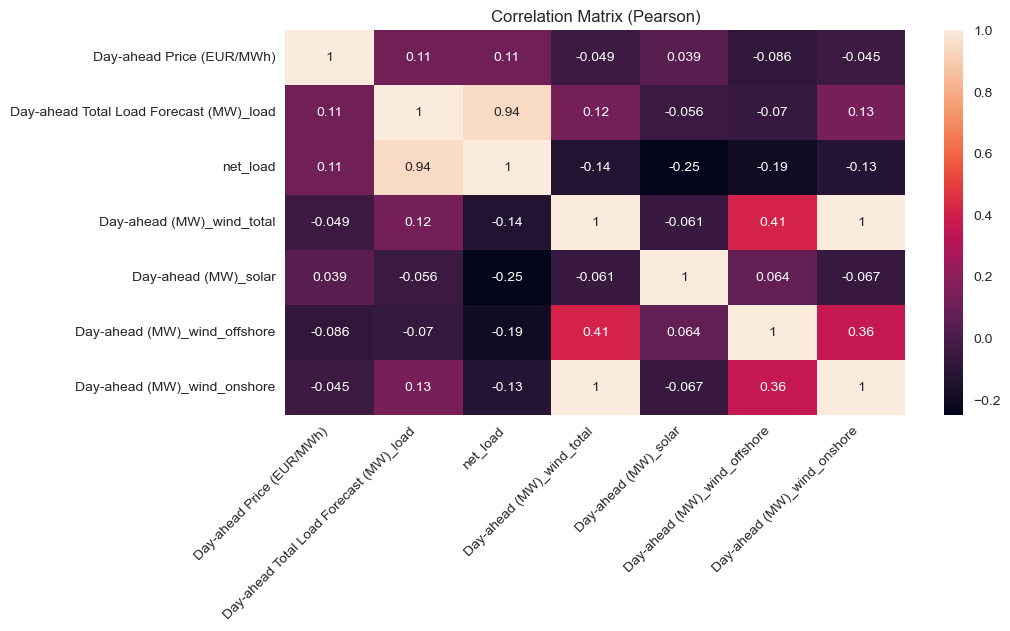

In [ ]:
corr_pearson = df_alls[(["Day-ahead Price (EUR/MWh)", 
                         "Day-ahead Total Load Forecast (MW)_load", 
                         "net_load", 
                         "Day-ahead (MW)_wind_total", 
                         "Day-ahead (MW)_solar", 
                         "Day-ahead (MW)_wind_offshore", 
                         "Day-ahead (MW)_wind_onshore"])].corr(method = "pearson")
plt.figure(figsize = (10, 5))
sns.heatmap(corr_pearson, annot=True)
plt.title("Correlation Matrix (Pearson)")
plt.xticks(rotation = 45, ha = "right")
plt.show()

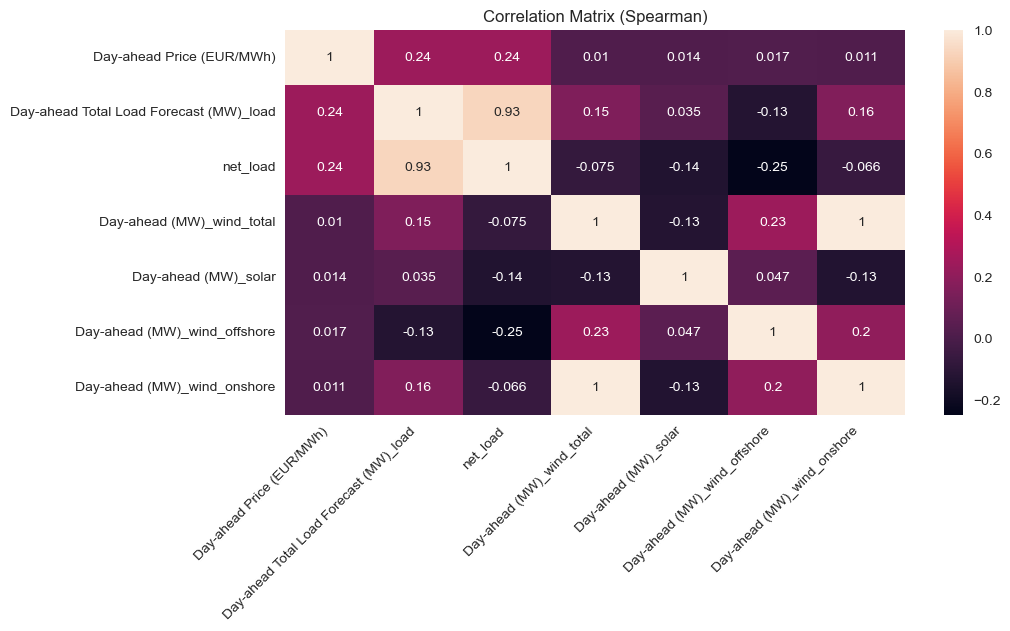

In [ ]:
corr_spearman = df_alls[(["Day-ahead Price (EUR/MWh)", 
                          "Day-ahead Total Load Forecast (MW)_load", 
                          "net_load", 
                          "Day-ahead (MW)_wind_total", 
                            "Day-ahead (MW)_solar", 
                            "Day-ahead (MW)_wind_offshore", 
                            "Day-ahead (MW)_wind_onshore"])].corr(method = "spearman")
plt.figure(figsize = (10, 5))
sns.heatmap(corr_spearman, annot=True)
plt.title("Correlation Matrix (Spearman)")
plt.xticks(rotation = 45, ha = "right")
plt.show()

In [70]:
r = df_alls["Day-ahead Total Load Forecast (MW)_load"].corr(df_alls["net_load"])
print(f"Total load vs net load correlation: {r:.3f}")

df_alls["renewable_share"] = (df_alls["renewable_load"] / 
                               df_alls["Day-ahead Total Load Forecast (MW)_load"])
print(df_alls["renewable_share"].describe())

Total load vs net load correlation: 0.943
count    78912.000000
mean         0.110038
std          0.081395
min          0.000000
25%          0.050817
50%          0.087222
75%          0.146283
max          0.683785
Name: renewable_share, dtype: float64


In [71]:
df_alls["load_diff"] = (df_alls["Day-ahead Total Load Forecast (MW)_load"] 
                        - df_alls["net_load"])

# What price behaviour accompanies the largest divergences?
high_divergence = df_alls[df_alls["load_diff"] > df_alls["load_diff"].quantile(0.9)]
low_divergence  = df_alls[df_alls["load_diff"] < df_alls["load_diff"].quantile(0.1)]

print("Mean price when renewables are high (large divergence):",
      high_divergence["Day-ahead Price (EUR/MWh)"].mean().round(1))
print("Mean price when renewables are low (small divergence):",
      low_divergence["Day-ahead Price (EUR/MWh)"].mean().round(1))

Mean price when renewables are high (large divergence): 69.7
Mean price when renewables are low (small divergence): 67.8


Spearman correlation shows stronger relationships between the net load and price which confirms the non-linear price formation. 

Net load shows the same correlation coefficient as day-ahead total load, which shows the interchangability between net load and total load. This observation has been varified through mean price when renewable is high and low. The net load has a higher correlation coefficient than renewable load, indicating the dominance of net load than renewable generations to the price. These details will be important for the modelling section.

### Residual Load Duration Curve (RLDC)

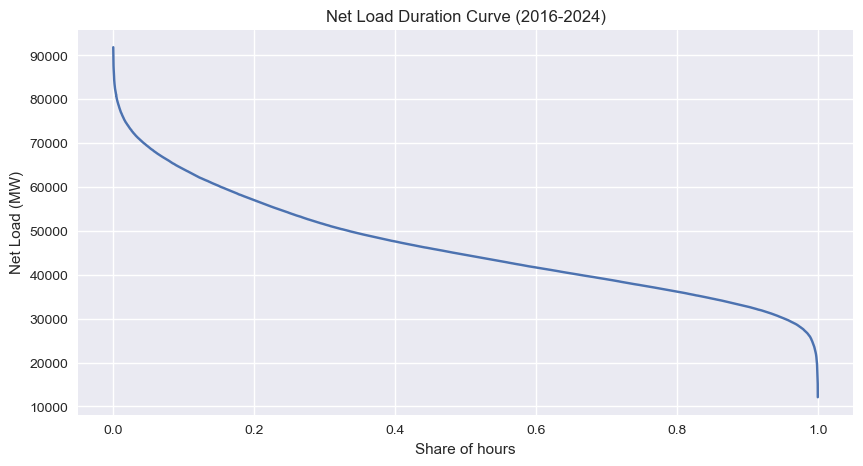

In [36]:
net_load_sorted = df_alls["net_load"].sort_values(ascending = False).reset_index(drop = True)
net_load_sorted.dropna(inplace = True)
x = net_load_sorted.index / len(net_load_sorted)
plt.figure(figsize = (10, 5))
plt.plot(x, net_load_sorted)
plt.xlabel("Share of hours")
plt.ylabel("Net Load (MW)")
plt.title("Net Load Duration Curve (2016-2024)")
plt.show()

In [37]:
np.percentile(net_load_sorted, [50, 95, 97, 99])

array([44544.145 , 69159.85  , 72082.6516, 77420.8448])

The hours where there is extremely high demand (> 72083 MW) are rare, about 3% of hours, roughly 260 hours per year. The gap between P95 (69160 MW) and P97 (72083 MW) is steep, indicating the sharp transition with the surrouding hours. For the remaining 95% of hours, net load stays below 69160 MW, meaning the system operates well within its dispatchable capacity envelope for the majority of the year. 

### Joint Interaction Influences On Day-ahead Price
#### Wind load, Total Load 

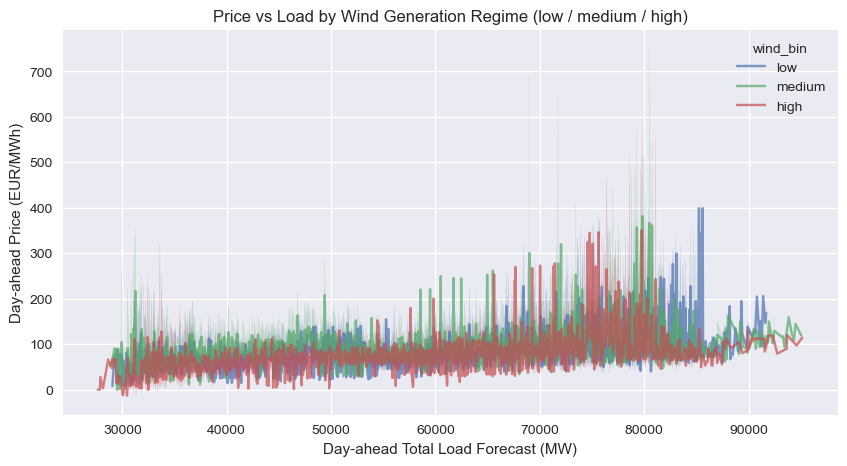

In [57]:
plt.figure(figsize = (10, 5))
sns.lineplot(
    data = df_alls.assign(wind_bin = pd.qcut(df_alls["Day-ahead (MW)_wind_total"], 3, 
                                          labels = ["low", "medium", "high"])),
    x = "Day-ahead Total Load Forecast (MW)_load",
    y= "Day-ahead Price (EUR/MWh)",
    hue = "wind_bin",
    alpha = 0.7
)

plt.xlabel("Day-ahead Total Load Forecast (MW)")
plt.ylabel("Day-ahead Price (EUR/MWh)")
plt.title("Price vs Load by Wind Generation Regime (low / medium / high)")
plt.show()

In [63]:
bins, edges = pd.qcut(df_alls["Day-ahead (MW)_wind_total"], 3, 
                           labels = ["low", "medium", "high"],
                           retbins = True)
print(edges)

df_alls["Day-ahead Total Load Forecast (MW)_load"].describe()

[    0.          2047.23        4145.22333333 21352.38      ]


count    78912.000000
mean     52082.498517
std      11548.198555
min      27650.000000
25%      43350.000000
50%      50250.000000
75%      59750.000000
max      95150.000000
Name: Day-ahead Total Load Forecast (MW)_load, dtype: float64

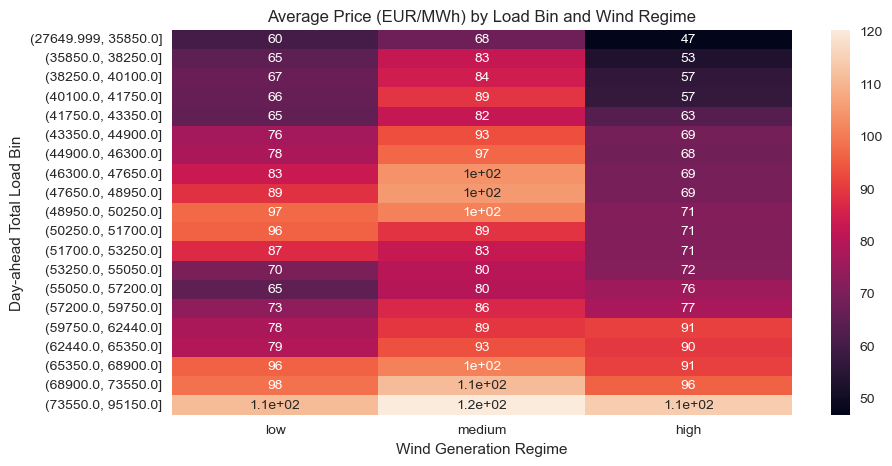

In [45]:
pivot_wind_load_price = df_alls.pivot_table(
    values = "Day-ahead Price (EUR/MWh)",
    index = df_alls.assign(
        total_load_bins = pd.qcut(
            df_alls["Day-ahead Total Load Forecast (MW)_load"], 20)
            )["total_load_bins"],
    columns = df_alls.assign(
        wind_bin = pd.qcut(df_alls["Day-ahead (MW)_wind_total"], 3, 
                           labels = ["low", "medium", "high"])
        )["wind_bin"],
    aggfunc = "mean",
    observed = False
)
plt.figure(figsize = (10, 5))
sns.heatmap(pivot_wind_load_price, annot=True)
plt.title("Average Price (EUR/MWh) by Load Bin and Wind Regime")
plt.xlabel("Wind Generation Regime")
plt.ylabel("Day-ahead Total Load Bin")
plt.show()

At medium load (~50250 MW), shifting from low to high wind reduces the average price by approximately 25 EUR/MWh, which shows a merit order displacement effect. At high demand (>65350 MW), the average price remains at about 100 EUR/MWh regardless of the wind generations, indicating scarcity conditions override the renewable suppression mechanism. 

#### Solar Load, Total Load

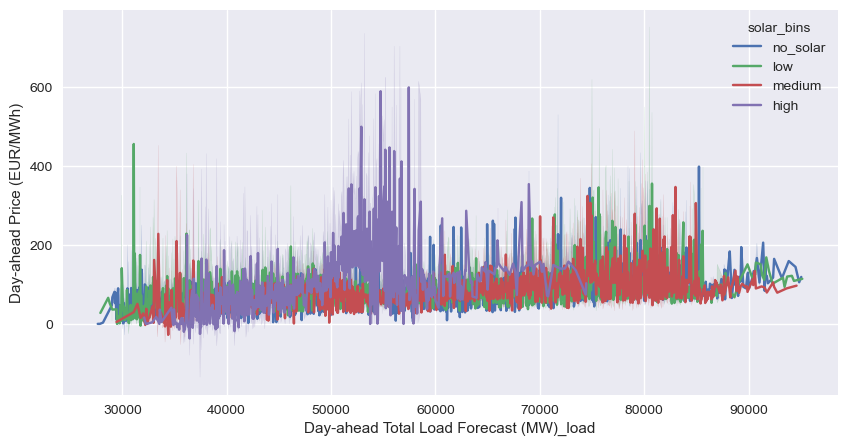

In [ ]:
max_solar = df_alls["Day-ahead (MW)_solar"].max()

plt.figure(figsize = (10, 5))
sns.lineplot(
    data = df_alls.assign(
        solar_bins = pd.cut(
            df_alls["Day-ahead (MW)_solar"], bins = [-1, 1, 0.1*max_solar, 0.5*max_solar, max_solar],
            labels = ["no_solar", "low", "medium", "high"])
    ),
    x= "Day-ahead Total Load Forecast (MW)_load",
    y= "Day-ahead Price (EUR/MWh)",
    hue= "solar_bins"
)
plt.xlabel("Day-ahead Total Load Forecast (MW)")
plt.ylabel("Day-ahead Price (EUR/MWh)")
plt.title("Price vs Load by Solar Generation Regime (no / low / medium / high)")
plt.show()

In [66]:
bins_solar, edges_solar = pd.cut(
    df_alls["Day-ahead (MW)_solar"],
    bins = [-1, 1, 0.1*max_solar, 0.5*max_solar, max_solar],
    labels = ["no_solar", "low", "medium", "high"],
    retbins= True
)
print(edges_solar)

[-1.000000e+00  1.000000e+00  1.532346e+03  7.661730e+03  1.532346e+04]


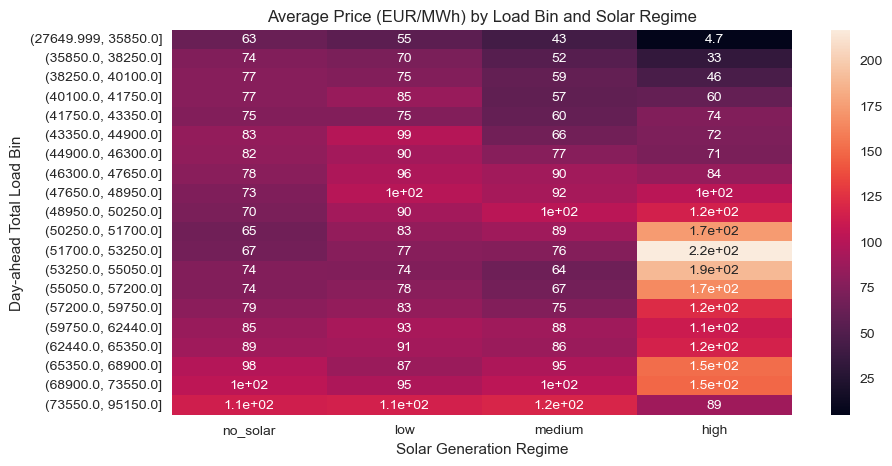

In [50]:
pivot_solar_load_price = df_alls.pivot_table(
    values="Day-ahead Price (EUR/MWh)",
    index = df_alls.assign(
        Forecast_load_bins = pd.qcut(
            df_alls["Day-ahead Total Load Forecast (MW)_load"], 20)
        )["Forecast_load_bins"],
    columns = df_alls.assign(
        solar_bins = pd.cut(df_alls["Day-ahead (MW)_solar"], bins = [
            -1, 1, 0.1 * max_solar, 0.5 * max_solar, max_solar
        ], labels = ["no_solar", "low", "medium", "high"])
    )["solar_bins"],
    aggfunc="mean",
    observed = False
)
plt.figure(figsize =(10, 5))
sns.heatmap(pivot_solar_load_price, annot=True)
plt.title("Average Price (EUR/MWh) by Load Bin and Solar Regime")
plt.xlabel("Solar Generation Regime")
plt.ylabel("Day-ahead Total Load Bin")
plt.show()

At low load range (27650 - 40100 MW) the increase of solar generations from zero to high ranges suppress the price steadily. This trend breaks down as total load surges, due to the fact that the solar generations cannot catch up with the speed of demand, which leads to several observations where the price keeps growing as the solar generations increase. 

At no solar periods, the price increases until the total load reaches medium range (~45000 MW) and decreases until ~53250 MW, which is the elbow point for the price to increase again. Interestingly, for all low, medium and high load generations this trend line for price holds true. 

## Summary of Price Driver Analysis
Across the 2016-2024 period, price formation in the French day-ahead market is driven by the aggregate balance of dispatchable demand and zero-marginal-cost supply, not by single variable in isolations. 

**Load** has a weak linear relationship with price (Pearson 0.11, Spearman 0.24), confirming load itself is a bad predictor for price. 

**Net load**, derived from subtracting renewable generations from total load, has the same Pearson and Spearman correlation coefficient to price. 

**Wind** suppresses price across all hours but lacks an interday cycle, meaning its effect is distributed rather than concentrated. Moving from the lowest to highest wind quintile reduces average price by ~34 EUR/MWh and compresses the P99 from 567 to 268 EUR/MWh.

**Solar** has a clear interday cycle and shows a non-linear relationship with price: low solar generations (< 4 GW) compress the price mean and variability. As the solar load levels > 4 GW, average and variability of the averaged price increase sharply as well as the tail risk. As the solar output reaches ~8 Gw, the average price decreases from 129 to 88 EUR/MWh, and the P99 decreases from 663 to 584 EUR/MWh.

While each renewable component exerts a measurable price impact individually, the marginal unit in the day-ahead market is ultimately determined by aggregate zero-marginal-cost supply. 

**Joint interactions** show that the price impact of wind and solar is load-dependent: 
renewable suppression is strongest at medium load levels and weakest during peak demand hours, when scarcity effects override the merit-order displacement mechanism. 

**RLDC curve** shows that for the remaining 95% of hours, net load stays below 69160 MW, meaning the system operates well within its dispatchable capacity envelope for the majority of the year. 

These findings directly motivate the feature engineering choices in "05_modelling.ipynb".